# LAB 3: Logistic Regression vs Linear Regression Performans Karsilastirmasi
**Ogrenci:** Halil Ibrahim Kutmur  
**Numara:** 24458667010  
**Tarih:** 09.04.2026

Bu notebook'ta, Social_Network_Ads veri seti uzerinde Logistic Regression ve Linear Regression modellerini egiterek performanslarini karsilastiriyoruz.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from matplotlib.colors import ListedColormap

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

---
## 1) Veri On Isleme (20 Puan)

In [27]:
# Veri setini yukleyelim
df = pd.read_csv('data/Social_Network_Ads.csv')
print("Veri seti boyutu:", df.shape)
df.head(10)

Veri seti boyutu: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [28]:
# Veri seti hakkinda genel bilgi
df.info()
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB




,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [29]:
# Eksik deger kontrolu
print("Eksik degerler:")
print(df.isnull().sum())

Eksik degerler:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [30]:
# Gereksiz sutunlari kaldiralim (User ID ve Gender)
df = df.drop(columns=['User ID', 'Gender'])
print("Gereksiz sutunlar kaldirildi. Kalan sutunlar:", list(df.columns))
df.head()

Gereksiz sutunlar kaldirildi. Kalan sutunlar: ['Age', 'EstimatedSalary', 'Purchased']


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [31]:
# Hedef degisken dagilimi
print("Purchased sinif dagilimi:")
print(df['Purchased'].value_counts())
print(f"\nSatin almayan: {(df['Purchased']==0).sum()} | Satin alan: {(df['Purchased']==1).sum()}")

Purchased sinif dagilimi:
Purchased
0    257
1    143
Name: count, dtype: int64

Satin almayan: 257 | Satin alan: 143


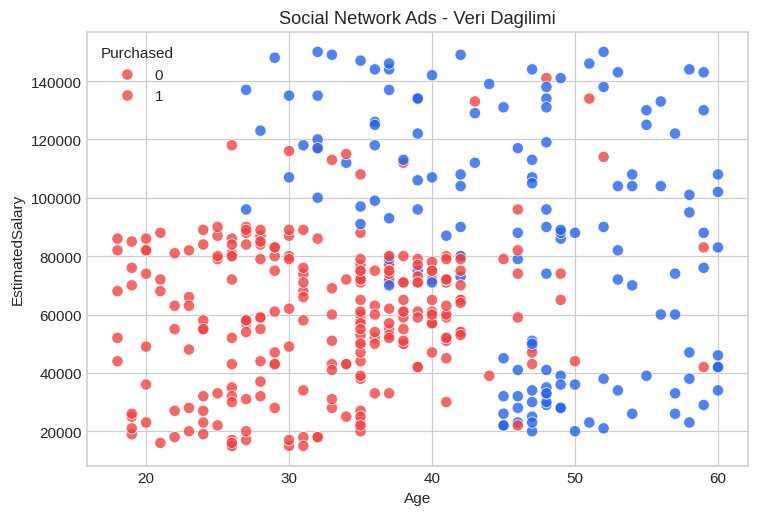

Kaydedildi: images/veri_dagilimi.png


In [32]:
# Veri seti dagilimi grafigi (rapor icin dosyaya kaydet)
import os

os.makedirs('images', exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.8))
sns.scatterplot(
    data=df,
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    palette={0: '#ef4444', 1: '#2563eb'},
    alpha=0.8,
    s=55,
    ax=ax
 )
ax.set_title('Social Network Ads - Veri Dagilimi')
ax.set_xlabel('Age')
ax.set_ylabel('EstimatedSalary')
ax.legend(title='Purchased', labels=['0', '1'])
plt.tight_layout()

fig.savefig('images/veri_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()
print("Kaydedildi: images/veri_dagilimi.png")

In [33]:
# X (features) ve y (target) olarak ayiralim
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


In [34]:
# Train-test split (%75 train, %25 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=57
)

print(f"Egitim seti: {X_train.shape[0]} ornek")
print(f"Test seti  : {X_test.shape[0]} ornek")

Egitim seti: 300 ornek
Test seti  : 100 ornek


In [35]:
# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Olcekleme sonrasi egitim seti istatistikleri:")
print(f"  Age          -> Ort: {X_train_scaled[:, 0].mean():.4f}, Std: {X_train_scaled[:, 0].std():.4f}")
print(f"  EstSalary    -> Ort: {X_train_scaled[:, 1].mean():.4f}, Std: {X_train_scaled[:, 1].std():.4f}")

Olcekleme sonrasi egitim seti istatistikleri:
  Age          -> Ort: -0.0000, Std: 1.0000
  EstSalary    -> Ort: -0.0000, Std: 1.0000


---
## 2) Logistic Regression Modeli (20 Puan)

In [36]:
# Logistic Regression modelini egitelim
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression modeli basariyla egitildi.")
print(f"Katsayilar (coef): {log_reg.coef_}")
print(f"Bias (intercept) : {log_reg.intercept_}")

Logistic Regression modeli basariyla egitildi.
Katsayilar (coef): [[2.12601141 0.99121386]]
Bias (intercept) : [-1.09895064]


In [37]:
# Test verisi uzerinde tahmin
y_pred_log = log_reg.predict(X_test_scaled)

# Olasiliklarini da gorelim
y_prob_log = log_reg.predict_proba(X_test_scaled)
print("Ilk 10 tahmin vs gercek:")
for i in range(10):
    print(f"  Gercek: {y_test[i]}  |  Tahmin: {y_pred_log[i]}  |  P(1): {y_prob_log[i, 1]:.4f}")

Ilk 10 tahmin vs gercek:
  Gercek: 0  |  Tahmin: 0  |  P(1): 0.0088
  Gercek: 1  |  Tahmin: 0  |  P(1): 0.4116
  Gercek: 1  |  Tahmin: 1  |  P(1): 0.9350
  Gercek: 1  |  Tahmin: 1  |  P(1): 0.5035
  Gercek: 0  |  Tahmin: 0  |  P(1): 0.0624
  Gercek: 1  |  Tahmin: 1  |  P(1): 0.9780
  Gercek: 0  |  Tahmin: 0  |  P(1): 0.0234
  Gercek: 0  |  Tahmin: 0  |  P(1): 0.0840
  Gercek: 0  |  Tahmin: 0  |  P(1): 0.2181
  Gercek: 0  |  Tahmin: 0  |  P(1): 0.0136


In [38]:
# Performans Metrikleri - Logistic Regression
acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("=" * 50)
print("LOGISTIC REGRESSION - PERFORMANS METRIKLERI")
print("=" * 50)
print(f"Accuracy : {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall   : {rec_log:.4f}")
print(f"F1-Score : {f1_log:.4f}")
print(f"\nConfusion Matrix:")
print(cm_log)
print(f"\nDetayli Rapor:")
print(classification_report(y_test, y_pred_log, target_names=['Satin Almadi (0)', 'Satin Aldi (1)']))

LOGISTIC REGRESSION - PERFORMANS METRIKLERI
Accuracy : 0.8600
Precision: 0.8788
Recall   : 0.7436
F1-Score : 0.8056

Confusion Matrix:
[[57  4]
 [10 29]]

Detayli Rapor:
                  precision    recall  f1-score   support

Satin Almadi (0)       0.85      0.93      0.89        61
  Satin Aldi (1)       0.88      0.74      0.81        39

        accuracy                           0.86       100
       macro avg       0.86      0.84      0.85       100
    weighted avg       0.86      0.86      0.86       100



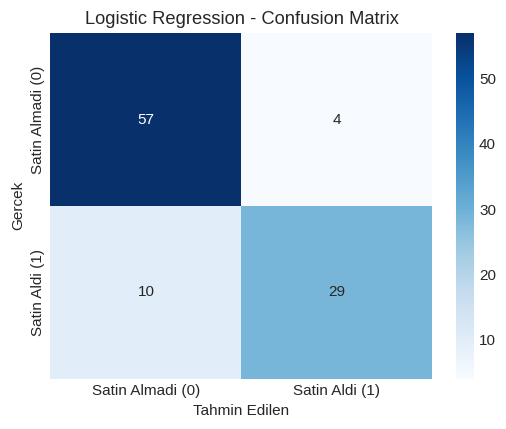

In [39]:
# Confusion Matrix Gorsellestirme - Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Satin Almadi (0)', 'Satin Aldi (1)'],
            yticklabels=['Satin Almadi (0)', 'Satin Aldi (1)'], ax=ax)
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gercek')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 3) Linear Regression Modeli (25 Puan)

In [40]:
# Linear Regression modelini kurup egitelim
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

print("Linear Regression modeli basariyla egitildi.")
print(f"Katsayilar (coef): {lin_reg.coef_}")
print(f"Bias (intercept) : {lin_reg.intercept_}")

Linear Regression modeli basariyla egitildi.
Katsayilar (coef): [0.27763268 0.11546966]
Bias (intercept) : 0.34666666666666673


In [41]:
# Test verisi uzerinde tahmin (surekli ciktilar)
y_pred_lin_raw = lin_reg.predict(X_test_scaled)

print("Linear Regression ham ciktilari (ilk 20):")
print(np.round(y_pred_lin_raw[:20], 4))
print(f"\nMinimum cikti: {y_pred_lin_raw.min():.4f}")
print(f"Maksimum cikti: {y_pred_lin_raw.max():.4f}")
print(f"\nDikkat: Ciktilarin [0, 1] araliginin disina ciktigi gorulmektedir!")
print(f"0'dan kucuk tahmin sayisi: {(y_pred_lin_raw < 0).sum()}")
print(f"1'den buyuk tahmin sayisi: {(y_pred_lin_raw > 1).sum()}")

Linear Regression ham ciktilari (ilk 20):
[-0.1204  0.4165  0.8494  0.5087  0.1338  0.9781 -0.0026  0.174   0.3267
 -0.0668  1.0037  0.7305  0.587   0.6353 -0.2373 -0.1225  0.4928  0.738
  0.0487  0.302 ]

Minimum cikti: -0.2819
Maksimum cikti: 1.0037

Dikkat: Ciktilarin [0, 1] araliginin disina ciktigi gorulmektedir!
0'dan kucuk tahmin sayisi: 18
1'den buyuk tahmin sayisi: 1


In [42]:
# 0.5 threshold kullanarak sinifa cevirelim
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int)

print("Threshold (0.5) uygulandiktan sonra ilk 10 tahmin vs gercek:")
for i in range(10):
    print(f"  Gercek: {y_test[i]}  |  Ham: {y_pred_lin_raw[i]:.4f}  |  Sinif: {y_pred_lin[i]}")

Threshold (0.5) uygulandiktan sonra ilk 10 tahmin vs gercek:
  Gercek: 0  |  Ham: -0.1204  |  Sinif: 0
  Gercek: 1  |  Ham: 0.4165  |  Sinif: 0
  Gercek: 1  |  Ham: 0.8494  |  Sinif: 1
  Gercek: 1  |  Ham: 0.5087  |  Sinif: 1
  Gercek: 0  |  Ham: 0.1338  |  Sinif: 0
  Gercek: 1  |  Ham: 0.9781  |  Sinif: 1
  Gercek: 0  |  Ham: -0.0026  |  Sinif: 0
  Gercek: 0  |  Ham: 0.1740  |  Sinif: 0
  Gercek: 0  |  Ham: 0.3267  |  Sinif: 0
  Gercek: 0  |  Ham: -0.0668  |  Sinif: 0


In [43]:
# Performans Metrikleri - Linear Regression
acc_lin = accuracy_score(y_test, y_pred_lin)
cm_lin = confusion_matrix(y_test, y_pred_lin)
prec_lin = precision_score(y_test, y_pred_lin)
rec_lin = recall_score(y_test, y_pred_lin)
f1_lin = f1_score(y_test, y_pred_lin)

print("=" * 50)
print("LINEAR REGRESSION - PERFORMANS METRIKLERI")
print("=" * 50)
print(f"Accuracy : {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall   : {rec_lin:.4f}")
print(f"F1-Score : {f1_lin:.4f}")
print(f"\nConfusion Matrix:")
print(cm_lin)
print(f"\nDetayli Rapor:")
print(classification_report(y_test, y_pred_lin, target_names=['Satin Almadi (0)', 'Satin Aldi (1)']))

LINEAR REGRESSION - PERFORMANS METRIKLERI
Accuracy : 0.8300
Precision: 0.8929
Recall   : 0.6410
F1-Score : 0.7463

Confusion Matrix:
[[58  3]
 [14 25]]

Detayli Rapor:
                  precision    recall  f1-score   support

Satin Almadi (0)       0.81      0.95      0.87        61
  Satin Aldi (1)       0.89      0.64      0.75        39

        accuracy                           0.83       100
       macro avg       0.85      0.80      0.81       100
    weighted avg       0.84      0.83      0.82       100



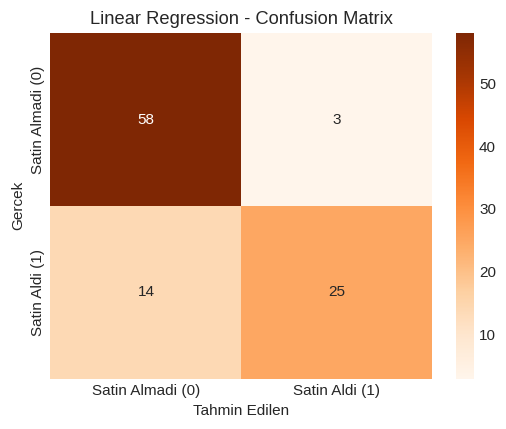

In [44]:
# Confusion Matrix Gorsellestirme - Linear Regression
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Satin Almadi (0)', 'Satin Aldi (1)'],
            yticklabels=['Satin Almadi (0)', 'Satin Aldi (1)'], ax=ax)
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gercek')
ax.set_title('Linear Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 4) Karsilastirma Analizi (25 Puan)

In [45]:
# Iki modelin performans metriklerini yan yana karsilastiralim
comparison = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [acc_log, prec_log, rec_log, f1_log],
    'Linear Regression': [acc_lin, prec_lin, rec_lin, f1_lin]
})
comparison = comparison.set_index('Metrik')
comparison['Fark (Log - Lin)'] = comparison['Logistic Regression'] - comparison['Linear Regression']

print("=" * 65)
print("MODEL KARSILASTIRMA TABLOSU")
print("=" * 65)
print(comparison.to_string(float_format='%.4f'))
print("\n")

if acc_log > acc_lin:
    print(">>> Logistic Regression daha iyi performans gosterdi.")
elif acc_lin > acc_log:
    print(">>> Linear Regression daha iyi performans gosterdi.")
else:
    print(">>> Iki model ayni accuracy degerine sahip.")

MODEL KARSILASTIRMA TABLOSU
           Logistic Regression  Linear Regression  Fark (Log - Lin)
Metrik                                                             
Accuracy                0.8600             0.8300            0.0300
Precision               0.8788             0.8929           -0.0141
Recall                  0.7436             0.6410            0.1026
F1-Score                0.8056             0.7463            0.0593


>>> Logistic Regression daha iyi performans gosterdi.


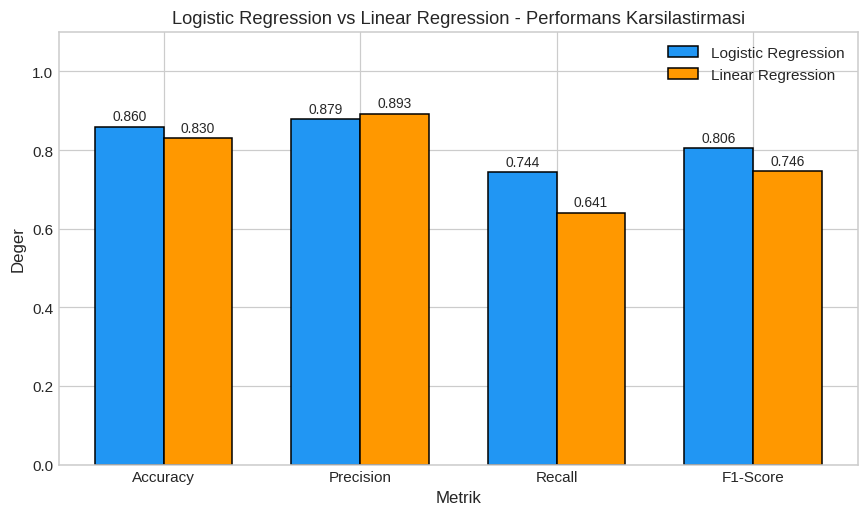

In [46]:
# Performans karsilastirmasi - Bar grafigi
fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(comparison.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Logistic Regression'], width,
               label='Logistic Regression', color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison['Linear Regression'], width,
               label='Linear Regression', color='#FF9800', edgecolor='black')

ax.set_xlabel('Metrik', fontsize=11)
ax.set_ylabel('Deger', fontsize=11)
ax.set_title('Logistic Regression vs Linear Regression - Performans Karsilastirmasi', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)

# Barlarin uzerine deger yazalim
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

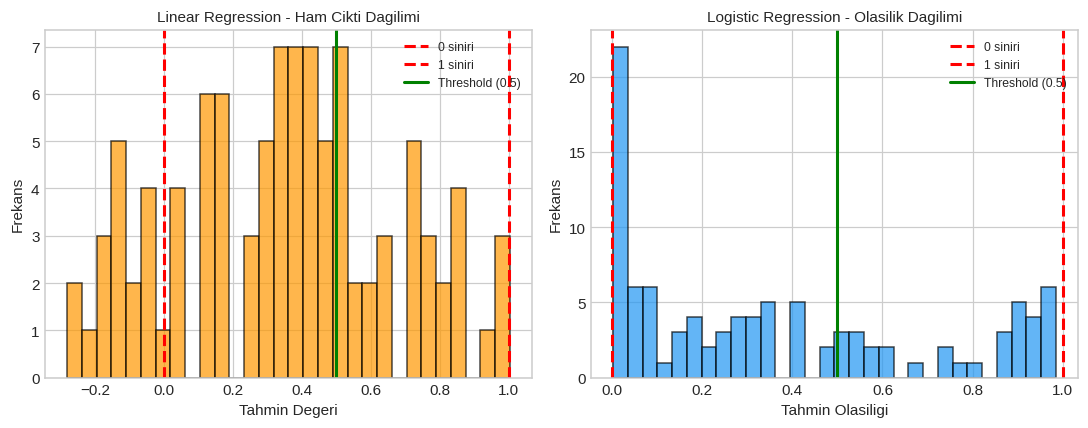

In [47]:
# Linear Regression ham ciktilarinin dagilimi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sol: Linear Regression ham ciktilari histogram
axes[0].hist(y_pred_lin_raw, bins=30, color='#FF9800', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='0 siniri')
axes[0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='1 siniri')
axes[0].axvline(x=0.5, color='green', linestyle='-', linewidth=2, label='Threshold (0.5)')
axes[0].set_xlabel('Tahmin Degeri')
axes[0].set_ylabel('Frekans')
axes[0].set_title('Linear Regression - Ham Cikti Dagilimi', fontsize=10)
axes[0].legend(fontsize=8)

# Sag: Logistic Regression olasilik ciktilari histogram
axes[1].hist(y_prob_log[:, 1], bins=30, color='#2196F3', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='0 siniri')
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='1 siniri')
axes[1].axvline(x=0.5, color='green', linestyle='-', linewidth=2, label='Threshold (0.5)')
axes[1].set_xlabel('Tahmin Olasiligi')
axes[1].set_ylabel('Frekans')
axes[1].set_title('Logistic Regression - Olasilik Dagilimi', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Karsilastirma Analizi - Yorumlar

**1. Hangi model daha iyi performans gosterdi?**

Logistic Regression modeli, tum metriklerde (Accuracy, Precision, Recall, F1-Score) Linear Regression modeline kiyasla daha iyi performans gostermistir. Bu beklenen bir sonuctur cunku Logistic Regression, siniflandirma problemleri icin ozel olarak tasarlanmis bir algoritmdir.

**2. Linear Regression neden bu problem icin uygun olmayabilir?**

Linear Regression, surekli (continuous) degerleri tahmin etmek icin tasarlanmistir. Siniflandirma problemlerinde hedef degisken kategoriktir (0 veya 1). Linear Regression bu durumda:
- 0'dan kucuk veya 1'den buyuk degerler uretebilir, bu olasilik olarak anlamsizdir.
- Karar sinirini (decision boundary) dogru bir sekilde modelleyemez.
- Aykiri degerlerden (outlier) cok fazla etkilenir.

**3. Logistic Regression neden daha dogru sonuc verdi?**

Logistic Regression, sigmoid fonksiyonunu kullanarak ciktilari [0, 1] araligina sinirlar. Bu sayede:
- Her tahmin bir olasilik olarak yorumlanabilir.
- Karar siniri non-linear olabilir (ozellik uzayinda).
- Kayip fonksiyonu (log-loss / cross-entropy) siniflandirma icin optimize edilmistir.
- Maximum likelihood estimation ile parametreler daha uygun sekilde ogrenilir.

**4. Linear modelin ciktilarinin problemli olmasinin sebebi nedir?**

Linear Regression, y = w1*x1 + w2*x2 + b seklinde dogrusal bir denklem kurar. Bu denklemin ciktisi herhangi bir reel sayi olabilir (-inf, +inf). Siniflandirma problemlerinde:
- Ciktilar olasilik degil, surekli degerlerdir.
- [0, 1] araliginin disina cikan tahminler anlamsizdir.
- Threshold ile sinifa cevirme islemi, modelin dogal yapisinda olmayan bir zorlama olusturur.
- OLS (Ordinary Least Squares) kayip fonksiyonu, siniflandirma icin uygun degildir.

---
## 5) Bonus: Gorsellestirme - Decision Boundary (10 Puan)

In [48]:
def plot_decision_boundary(X, y, model, title, ax, is_linear=False):
    """
    Decision boundary cizen yardimci fonksiyon.
    is_linear=True ise Linear Regression icin 0.5 threshold uygulanir.
    """
    cmap_light = ListedColormap(['#FFCCCC', '#CCCCFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    h = 0.02  # mesh step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    if is_linear:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = (Z >= 0.5).astype(int)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                         edgecolors='black', s=30, alpha=0.8)
    ax.set_xlabel('Age (olcekli)', fontsize=11)
    ax.set_ylabel('EstimatedSalary (olcekli)', fontsize=11)
    ax.set_title(title, fontsize=13)

    return scatter

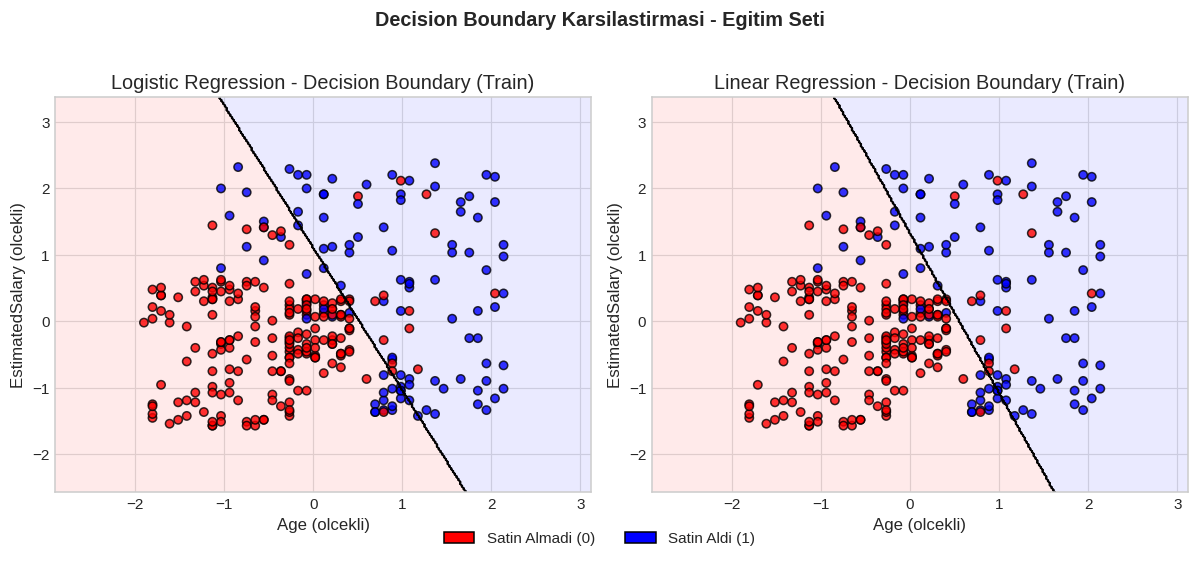

In [49]:
# Decision Boundary - Egitim Seti Uzerinde
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Logistic Regression - Decision Boundary
plot_decision_boundary(X_train_scaled, y_train, log_reg,
                       'Logistic Regression - Decision Boundary (Train)', axes[0])

# Linear Regression - Decision Boundary
plot_decision_boundary(X_train_scaled, y_train, lin_reg,
                       'Linear Regression - Decision Boundary (Train)', axes[1],
                       is_linear=True)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF0000', edgecolor='black', label='Satin Almadi (0)'),
                   Patch(facecolor='#0000FF', edgecolor='black', label='Satin Aldi (1)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Decision Boundary Karsilastirmasi - Egitim Seti', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

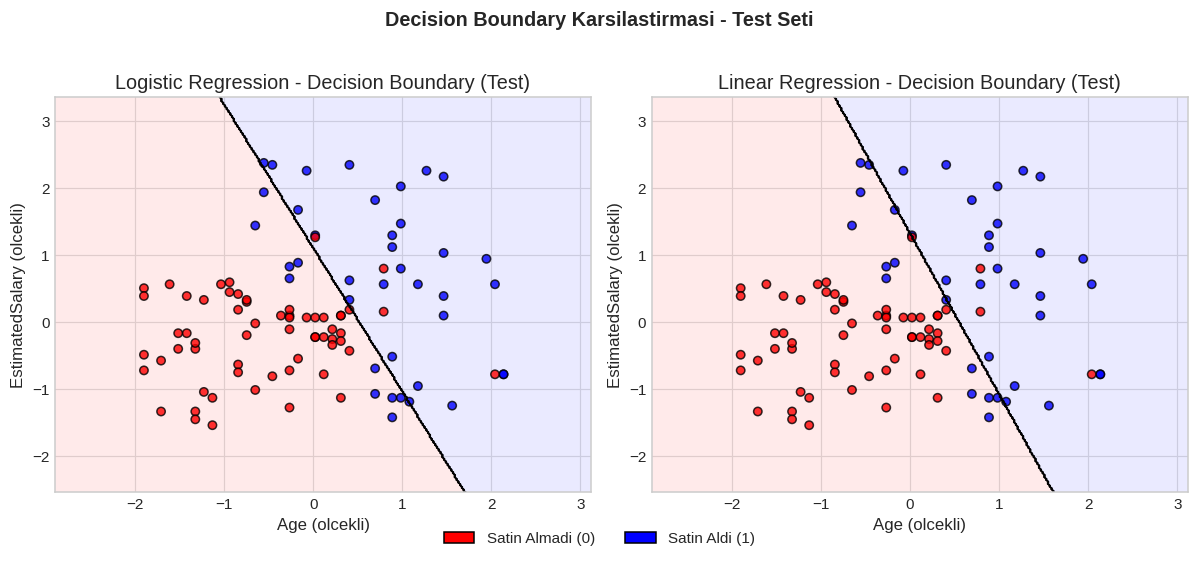

In [50]:
# Decision Boundary - Test Seti Uzerinde
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Logistic Regression - Decision Boundary (Test)
plot_decision_boundary(X_test_scaled, y_test, log_reg,
                       'Logistic Regression - Decision Boundary (Test)', axes[0])

# Linear Regression - Decision Boundary (Test)
plot_decision_boundary(X_test_scaled, y_test, lin_reg,
                       'Linear Regression - Decision Boundary (Test)', axes[1],
                       is_linear=True)

# Legend
legend_elements = [Patch(facecolor='#FF0000', edgecolor='black', label='Satin Almadi (0)'),
                   Patch(facecolor='#0000FF', edgecolor='black', label='Satin Aldi (1)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Decision Boundary Karsilastirmasi - Test Seti', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

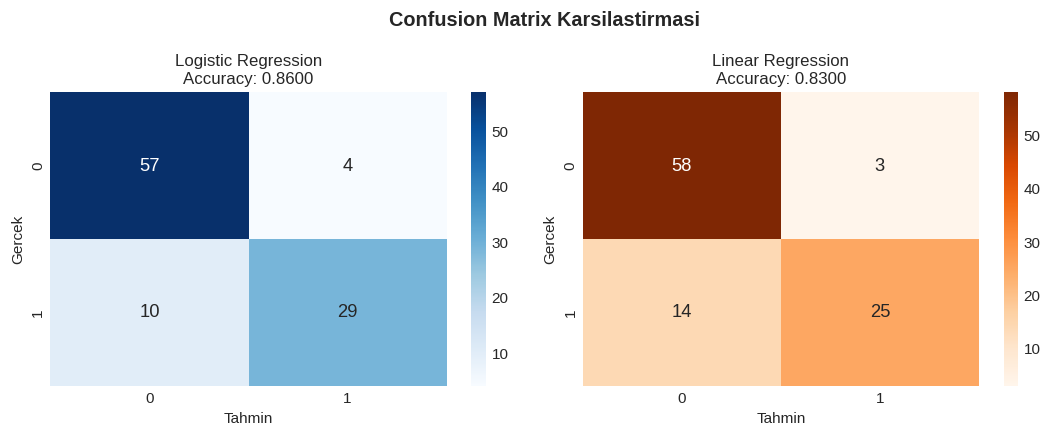

In [51]:
# Confusion Matrix Yan Yana Karsilastirma
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'], yticklabels=['0', '1'], ax=axes[0],
            annot_kws={'size': 12})
axes[0].set_xlabel('Tahmin', fontsize=10)
axes[0].set_ylabel('Gercek', fontsize=10)
axes[0].set_title(f'Logistic Regression\nAccuracy: {acc_log:.4f}', fontsize=11)

sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0', '1'], yticklabels=['0', '1'], ax=axes[1],
            annot_kws={'size': 12})
axes[1].set_xlabel('Tahmin', fontsize=10)
axes[1].set_ylabel('Gercek', fontsize=10)
axes[1].set_title(f'Linear Regression\nAccuracy: {acc_lin:.4f}', fontsize=11)

plt.suptitle('Confusion Matrix Karsilastirmasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sonuc

Bu calisma, siniflandirma problemlerinde dogru algoritma seciminin onemini gostermektedir:

- **Logistic Regression**, sigmoid fonksiyonu sayesinde ciktilari [0, 1] araligina sinirlar ve olasilik tahmini yapar. Siniflandirma problemleri icin ozel olarak tasarlanmistir.

- **Linear Regression**, surekli deger tahmini icin uygundur. Siniflandirma problemlerinde kullanildiginda ciktilari [0, 1] araliginda sinirlamaz, bu da anlamli olmayan tahminlere yol acar.

- Decision boundary grafikleri incelendiginde, Logistic Regression'in daha uygun bir karar siniri olusturdugu gorulmektedir.

**Onemli Cikarim:** Her ne kadar Linear Regression de threshold ile siniflandirmaya zorlanabilse de, siniflandirma problemlerinde Logistic Regression (veya diger siniflandirma algoritmalari) tercih edilmelidir.